# START

# cek names data and machine

In [1]:
import tensorflow as tf

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

2026-05-22 15:32:50.273398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779463970.523868      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779463970.606471      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779463971.168280      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779463971.168317      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779463971.168320      57 computation_placer.cc:177] computation placer alr

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hafizhumarhaq/data-1/student_mental_health_selected_features.csv


# CEK RESIKO LEVEL

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/hafizhumarhaq/data-1/student_mental_health_selected_features.csv')

df.head()

,stress_level,anxiety_score,depression_score,exam_pressure,sleep_hours,study_hours_per_day,financial_stress,family_expectation,social_support,physical_activity,burnout_score,mental_health_index,risk_level,mental_health_category
0,4.116950,2.275713,1.986730,6.487218,6.880545,5.596071,3.446626,3.586147,6.470080,2.728861,2.037344,7.074487,0,2
1,0.349489,0.000000,0.000000,5.631481,7.463339,5.597171,2.814039,5.478666,0.000000,3.690866,0.000000,9.860204,0,2
2,3.476177,2.425201,0.851996,6.015297,8.946670,2.580491,4.918515,6.068155,6.901725,3.296720,0.000000,7.626370,0,2
3,6.778843,4.512425,4.285645,6.684005,4.571380,4.607208,6.915885,6.557540,2.349857,2.065480,7.227651,4.649042,2,1
4,1.854595,1.102558,0.000000,4.010945,5.989324,2.186569,4.382820,5.934779,4.512921,4.026504,0.000000,8.927394,0,2


In [4]:
print(df.columns)

Index(['stress_level', 'anxiety_score', 'depression_score', 'exam_pressure',
       'sleep_hours', 'study_hours_per_day', 'financial_stress',
       'family_expectation', 'social_support', 'physical_activity',
       'burnout_score', 'mental_health_index', 'risk_level',
       'mental_health_category'],
      dtype='object')


In [5]:
print(df["risk_level"].value_counts())

risk_level
0    766645
1    218275
2     15080
Name: count, dtype: int64


# install library

In [6]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

# load dataset

In [8]:
df = pd.read_csv(
    '/kaggle/input/datasets/hafizhumarhaq/data-1/student_mental_health_selected_features.csv'
)

df.head()

,stress_level,anxiety_score,depression_score,exam_pressure,sleep_hours,study_hours_per_day,financial_stress,family_expectation,social_support,physical_activity,burnout_score,mental_health_index,risk_level,mental_health_category
0,4.116950,2.275713,1.986730,6.487218,6.880545,5.596071,3.446626,3.586147,6.470080,2.728861,2.037344,7.074487,0,2
1,0.349489,0.000000,0.000000,5.631481,7.463339,5.597171,2.814039,5.478666,0.000000,3.690866,0.000000,9.860204,0,2
2,3.476177,2.425201,0.851996,6.015297,8.946670,2.580491,4.918515,6.068155,6.901725,3.296720,0.000000,7.626370,0,2
3,6.778843,4.512425,4.285645,6.684005,4.571380,4.607208,6.915885,6.557540,2.349857,2.065480,7.227651,4.649042,2,1
4,1.854595,1.102558,0.000000,4.010945,5.989324,2.186569,4.382820,5.934779,4.512921,4.026504,0.000000,8.927394,0,2


In [9]:
df = df.dropna()

print(df.isnull().sum())

stress_level              0
anxiety_score             0
depression_score          0
exam_pressure             0
sleep_hours               0
study_hours_per_day       0
financial_stress          0
family_expectation        0
social_support            0
physical_activity         0
burnout_score             0
mental_health_index       0
risk_level                0
mental_health_category    0
dtype: int64


# feature & target

In [10]:
# FEATURE
X = df[[
    'stress_level',
    'anxiety_score',
    'depression_score',
    'exam_pressure',
    'sleep_hours',
    'study_hours_per_day',
    'financial_stress',
    'family_expectation',
    'social_support',
    'physical_activity'
]]

# TARGET BURNOUT
y_burnout = df['risk_level']

# TARGET MENTAL HEALTH
y_mental = df['mental_health_category']

# scaling data

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# split dataset

In [12]:
# Burnout split
X_train_burnout, X_test_burnout, y_train_burnout, y_test_burnout = train_test_split(
    X_scaled,
    y_burnout,
    test_size=0.2,
    random_state=42
)

# Mental health split
X_train_mental, X_test_mental, y_train_mental, y_test_mental = train_test_split(
    X_scaled,
    y_mental,
    test_size=0.2,
    random_state=42
)

# custom callback

In [61]:
import tensorflow as tf

In [62]:
class TrainingCallback(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        logs = logs or {}

        acc = logs.get('val_accuracy')

        if acc is not None and acc >= 0.999:

            print("\nTarget accuracy tercapai!")

            self.model.stop_training = True

# build burnout model 

In [15]:
burnout_inputs = Input(shape=(10,))

x = Dense(256, activation='relu')(burnout_inputs)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)

burnout_outputs = Dense(
    3,
    activation='softmax'
)(x)

burnout_model = Model(
    inputs=burnout_inputs,
    outputs=burnout_outputs
)

burnout_model.summary()

I0000 00:00:1779464009.348539      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779464009.354506      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,699 (178.51 KB)

 Trainable params: 44,931 (175.51 KB)

 Non-trainable params: 768 (3.00 KB)

# build mental model

In [16]:
mental_inputs = Input(shape=(10,))

y = Dense(256, activation='relu')(mental_inputs)
y = BatchNormalization()(y)
y = Dropout(0.4)(y)

y = Dense(128, activation='relu')(y)
y = BatchNormalization()(y)
y = Dropout(0.3)(y)

y = Dense(64, activation='relu')(y)

mental_outputs = Dense(
    3,
    activation='softmax'
)(y)

mental_model = Model(
    inputs=mental_inputs,
    outputs=mental_outputs
)

mental_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,699 (178.51 KB)

 Trainable params: 44,931 (175.51 KB)

 Non-trainable params: 768 (3.00 KB)

In [17]:
mental_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# compile burnout model

In [18]:
import tensorflow as tf

In [19]:
burnout_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# training  burnout model

In [20]:
history_burnout = burnout_model.fit(
    X_train_burnout,
    y_train_burnout,

    validation_split=0.2,

    epochs=50,
    batch_size=32,

    callbacks=[
        TrainingCallback()
    ],

    verbose=1
)

Epoch 1/50


I0000 00:00:1779464012.934398     135 service.cc:152] XLA service 0x7a9f10011090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779464012.934436     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779464012.934440     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779464013.352890     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


   67/20000 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.5705 - loss: 1.0693  

I0000 00:00:1779464015.531856     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20000/20000 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - accuracy: 0.8497 - loss: 0.3480 - val_accuracy: 0.8656 - val_loss: 0.3037
Epoch 2/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.8606 - loss: 0.3153 - val_accuracy: 0.8657 - val_loss: 0.3035
Epoch 3/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.8632 - loss: 0.3110 - val_accuracy: 0.8658 - val_loss: 0.3025
Epoch 4/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8643 - loss: 0.3084 - val_accuracy: 0.8667 - val_loss: 0.3037
Epoch 5/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - accuracy: 0.8653 - loss: 0.3066 - val_accuracy: 0.8652 - val_loss: 0.3036
Epoch 6/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8651 - loss: 0.3069 - val_accuracy: 0.8661 - val_loss: 0.3021
Epoch 7/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.8648 - loss: 0.3068 - val_accuracy: 0.8660 - val_loss: 0.3022
Epoch 8/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.8656 - lo

# training mental model

In [29]:
mental_inputs = Input(shape=(10,))

y = Dense(256, activation='relu')(mental_inputs)
y = BatchNormalization()(y)
y = Dropout(0.4)(y)

y = Dense(128, activation='relu')(y)
y = BatchNormalization()(y)
y = Dropout(0.3)(y)

y = Dense(64, activation='relu')(y)

mental_outputs = Dense(
    3,
    activation='softmax'
)(y)

mental_model = Model(
    inputs=mental_inputs,
    outputs=mental_outputs
)

mental_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,699 (178.51 KB)

 Trainable params: 44,931 (175.51 KB)

 Non-trainable params: 768 (3.00 KB)

# compile mental model

In [31]:
mental_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# train mental model

In [63]:
history_mental = mental_model.fit(
    X_train_mental,
    y_train_mental,

    validation_split=0.2,

    epochs=50,
    batch_size=32,

    callbacks=[
        TrainingCallback()
    ],

    verbose=1
)

Epoch 1/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.9892 - loss: 0.0267 - val_accuracy: 0.9939 - val_loss: 0.0153
Epoch 2/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.9910 - loss: 0.0222 - val_accuracy: 0.9959 - val_loss: 0.0135
Epoch 3/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.9916 - loss: 0.0202 - val_accuracy: 0.9957 - val_loss: 0.0113
Epoch 4/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.9924 - loss: 0.0187 - val_accuracy: 0.9948 - val_loss: 0.0123
Epoch 5/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.9931 - loss: 0.0174 - val_accuracy: 0.9945 - val_loss: 0.0127
Epoch 6/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9930 - loss: 0.0173 - val_accuracy: 0.9970 - val_loss: 0.0104
Epoch 7/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9935 - loss: 0.0164 - val_accuracy: 0.9966 - val_loss: 0.0103
Epoch 8/50
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 

# prediksi burnout

In [21]:
import numpy as np

# Prediksi burnout
y_pred_burnout = burnout_model.predict(
    X_test_burnout
)

# Ambil kelas probabilitas tertinggi
y_pred_burnout_classes = np.argmax(
    y_pred_burnout,
    axis=1
)

print(
    y_pred_burnout_classes[:10]
)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
[0 0 0 1 0 1 1 0 0 0]


# prediksi mental health

In [35]:
# Prediksi mental health
y_pred_mental = mental_model.predict(
    X_test_mental
)

# Ambil kelas probabilitas tertinggi
y_pred_mental_classes = np.argmax(
    y_pred_mental,
    axis=1
)

print(
    y_pred_mental_classes[:10]
)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
[2 1 2 1 2 1 1 2 2 2]


# akurasi burnout

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_burnout,
    y_pred_burnout_classes
))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92    153333
           1       0.71      0.66      0.69     43592
           2       0.66      0.23      0.34      3075

    accuracy                           0.87    200000
   macro avg       0.76      0.61      0.65    200000
weighted avg       0.86      0.87      0.86    200000



In [25]:
from sklearn.metrics import accuracy_score

burnout_accuracy = accuracy_score(
    y_test_burnout,
    y_pred_burnout_classes
)

print(
    f"Burnout Accuracy : {burnout_accuracy * 100:.2f}%"
)

Burnout Accuracy : 86.77%


In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_burnout,
    y_pred_burnout_classes
))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92    153333
           1       0.71      0.66      0.69     43592
           2       0.66      0.23      0.34      3075

    accuracy                           0.87    200000
   macro avg       0.76      0.61      0.65    200000
weighted avg       0.86      0.87      0.86    200000



# akurasi mental health

In [38]:
# Prediksi mental health
y_pred_mental = mental_model.predict(
    X_test_mental
)

# Ambil kelas probabilitas tertinggi
y_pred_mental_classes = np.argmax(
    y_pred_mental,
    axis=1
)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


In [39]:
from sklearn.metrics import accuracy_score

mental_accuracy = accuracy_score(
    y_test_mental,
    y_pred_mental_classes
)

print(
    f"Mental Health Accuracy : {mental_accuracy * 100:.2f}%"
)

Mental Health Accuracy : 99.31%


In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_mental,
    y_pred_mental_classes
))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      2783
           1       1.00      0.99      0.99     92953
           2       0.99      1.00      1.00    104264

    accuracy                           0.99    200000
   macro avg       0.94      0.99      0.96    200000
weighted avg       0.99      0.99      0.99    200000



# classification report

In [46]:
from sklearn.metrics import classification_report

# =========================
# BURNOUT REPORT
# =========================

print("========== BURNOUT MODEL ==========\n")

burnout_report = classification_report(
    y_test_burnout,
    y_pred_burnout_classes,
    output_dict=True
)

for label, metrics in burnout_report.items():

    if isinstance(metrics, dict):

        print(f"\nClass {label}")

        print(
            f"Precision : {metrics['precision'] * 100:.2f}%"
        )

        print(
            f"Recall    : {metrics['recall'] * 100:.2f}%"
        )

        print(
            f"F1-Score  : {metrics['f1-score'] * 100:.2f}%"
        )


# =========================
# MENTAL HEALTH REPORT
# =========================

print("\n\n========== MENTAL HEALTH MODEL ==========\n")

mental_report = classification_report(
    y_test_mental,
    y_pred_mental_classes,
    output_dict=True
)

for label, metrics in mental_report.items():

    if isinstance(metrics, dict):

        print(f"\nClass {label}")

        print(
            f"Precision : {metrics['precision'] * 100:.2f}%"
        )

        print(
            f"Recall    : {metrics['recall'] * 100:.2f}%"
        )

        print(
            f"F1-Score  : {metrics['f1-score'] * 100:.2f}%"
        )

========== BURNOUT MODEL ==========


Class 0
Precision : 90.87%
Recall    : 93.94%
F1-Score  : 92.38%

Class 1
Precision : 71.21%
Recall    : 66.02%
F1-Score  : 68.52%

Class 2
Precision : 66.45%
Recall    : 23.25%
F1-Score  : 34.45%

Class macro avg
Precision : 76.18%
Recall    : 61.07%
F1-Score  : 65.12%

Class weighted avg
Precision : 86.21%
Recall    : 86.77%
F1-Score  : 86.29%


========== MENTAL HEALTH MODEL ==========


Class 0
Precision : 81.41%
Recall    : 98.81%
F1-Score  : 89.27%

Class 1
Precision : 99.87%
Recall    : 98.64%
F1-Score  : 99.25%

Class 2
Precision : 99.39%
Recall    : 99.92%
F1-Score  : 99.65%

Class macro avg
Precision : 93.56%
Recall    : 99.12%
F1-Score  : 96.06%

Class weighted avg
Precision : 99.36%
Recall    : 99.31%
F1-Score  : 99.32%


In [53]:
from sklearn.metrics import classification_report

print("===== BURNOUT MODEL =====")

print(classification_report(
    y_test_burnout,
    y_pred_burnout_classes
))

print("\n===== MENTAL HEALTH MODEL =====")

print(classification_report(
    y_test_mental,
    y_pred_mental_classes
))

===== BURNOUT MODEL =====
              precision    recall  f1-score   support

           0       0.91      0.94      0.92    153333
           1       0.71      0.66      0.69     43592
           2       0.66      0.23      0.34      3075

    accuracy                           0.87    200000
   macro avg       0.76      0.61      0.65    200000
weighted avg       0.86      0.87      0.86    200000


===== MENTAL HEALTH MODEL =====
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      2783
           1       1.00      0.99      0.99     92953
           2       0.99      1.00      1.00    104264

    accuracy                           0.99    200000
   macro avg       0.94      0.99      0.96    200000
weighted avg       0.99      0.99      0.99    200000



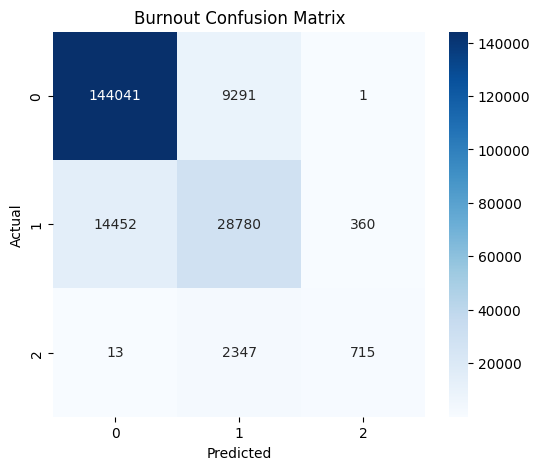

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Burnout confusion matrix
cm_burnout = confusion_matrix(
    y_test_burnout,
    y_pred_burnout_classes
)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_burnout,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Burnout Confusion Matrix")

plt.show()

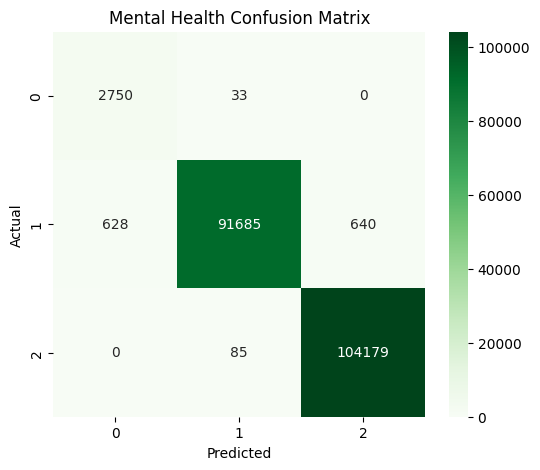

In [67]:
# Mental health confusion matrix
cm_mental = confusion_matrix(
    y_test_mental,
    y_pred_mental_classes
)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mental,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Mental Health Confusion Matrix")

plt.show()

# grafik akurasi

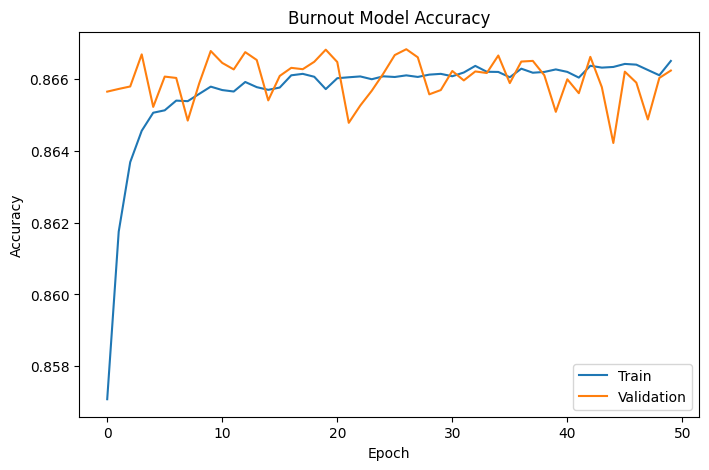

In [56]:
import matplotlib.pyplot as plt

# Accuracy Burnout
plt.figure(figsize=(8,5))

plt.plot(
    history_burnout.history['accuracy'],
    label='Train'
)

plt.plot(
    history_burnout.history['val_accuracy'],
    label='Validation'
)

plt.title('Burnout Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

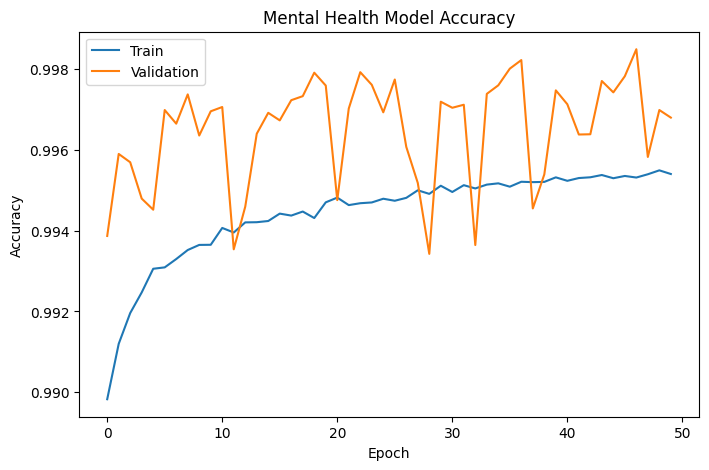

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    history_mental.history['accuracy'],
    label='Train'
)

plt.plot(
    history_mental.history['val_accuracy'],
    label='Validation'
)

plt.title('Mental Health Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

# grafik loss

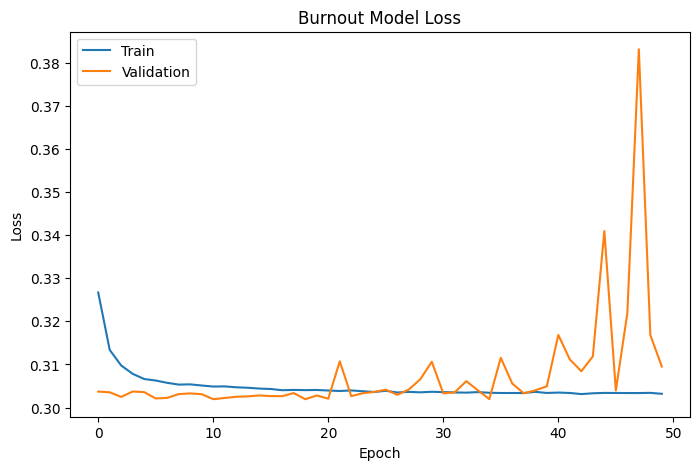

In [68]:
# Loss Burnout
plt.figure(figsize=(8,5))

plt.plot(
    history_burnout.history['loss'],
    label='Train'
)

plt.plot(
    history_burnout.history['val_loss'],
    label='Validation'
)

plt.title('Burnout Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

# simpan model

untuk API

In [77]:
# Save burnout model
burnout_model.save(
    "burnout_model.keras"
)

# Save mental health model
mental_model.save(
    "mental_health_model.keras"
)

# simpan scaler

In [79]:
import joblib

joblib.dump(
    scaler,
    "scaler.save"
)

['scaler.save']

# prediksi data baru

In [80]:
import pandas as pd
import numpy as np

# Data baru
new_data = pd.DataFrame(
    [[1,2,3,4,5,6,7,8,9,10]],
    columns=X.columns
)

# Scaling
new_data_scaled = scaler.transform(
    new_data
)

# =========================
# PREDIKSI BURNOUT
# =========================

burnout_prediction = burnout_model.predict(
    new_data_scaled
)

burnout_class = burnout_prediction.argmax(
    axis=1
)

# =========================
# PREDIKSI MENTAL HEALTH
# =========================

mental_prediction = mental_model.predict(
    new_data_scaled
)

mental_class = mental_prediction.argmax(
    axis=1
)

# =========================
# LABEL
# =========================

burnout_labels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

mental_labels = {
    0: "Buruk",
    1: "Sedang",
    2: "Baik"
}

# =========================
# OUTPUT
# =========================

print(
    "Burnout Prediction :",
    burnout_labels[burnout_class[0]]
)

print(
    "Mental Health Prediction :",
    mental_labels[mental_class[0]]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
Burnout Prediction : Low
Mental Health Prediction : Baik


# inference

In [81]:
import tensorflow as tf
import numpy as np
import pandas as pd

# =========================
# SAVE MODEL
# =========================

burnout_model.save(
    "burnout_model.keras"
)

mental_model.save(
    "mental_health_model.keras"
)

# =========================
# LOAD MODEL
# =========================

loaded_burnout_model = tf.keras.models.load_model(
    "burnout_model.keras"
)

loaded_mental_model = tf.keras.models.load_model(
    "mental_health_model.keras"
)

# =========================
# SAMPLE DATA
# =========================

sample_data = pd.DataFrame([[
    8,
    7,
    6,
    9,
    4,
    7,
    8,
    7,
    3,
    2
]], columns=X.columns)

# =========================
# SCALING
# =========================

sample_scaled = scaler.transform(
    sample_data
)

# =========================
# BURNOUT PREDICTION
# =========================

burnout_prediction = loaded_burnout_model.predict(
    sample_scaled
)

burnout_class = np.argmax(
    burnout_prediction
)

# =========================
# MENTAL HEALTH PREDICTION
# =========================

mental_prediction = loaded_mental_model.predict(
    sample_scaled
)

mental_class = np.argmax(
    mental_prediction
)

# =========================
# LABELS
# =========================

burnout_labels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

mental_labels = {
    0: "Buruk",
    1: "Sedang",
    2: "Baik"
}

# =========================
# OUTPUT
# =========================

print(
    "Prediksi Burnout:",
    burnout_labels[burnout_class]
)

print(
    "Prediksi Mental Health:",
    mental_labels[mental_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
Prediksi Burnout: Medium
Prediksi Mental Health: Buruk


# download file

In [82]:
import zipfile
import os

zip_path = "/kaggle/working/burnout_project_files.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:

    files = [
        "best_model.keras",
        "burnout_model.keras",
        "mental_health_model.keras",
        "scaler.save"
    ]

    for file in files:

        file_path = f"/kaggle/working/{file}"

        if os.path.exists(file_path):

            zipf.write(
                file_path,
                arcname=file
            )

print("ZIP berhasil dibuat!")
print(os.listdir('/kaggle/working'))

ZIP berhasil dibuat!
['burnout_project_files.zip', 'burnout_model.keras', 'scaler.save', '.virtual_documents', 'mental_health_model.keras']


# requirement txt 


In [1]:
requirements_text = """
tensorflow==2.16.1
fastapi==0.115.0
uvicorn==0.30.6
numpy==1.26.4
pandas==2.2.2
scikit-learn==1.5.1
joblib==1.4.2
python-multipart==0.0.9
"""

with open("/kaggle/working/requirements.txt", "w") as f:
    f.write(requirements_text)

print("requirements.txt berhasil dibuat!")

requirements.txt berhasil dibuat!
